<a href="https://colab.research.google.com/github/Solo7602/web/blob/5lab/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

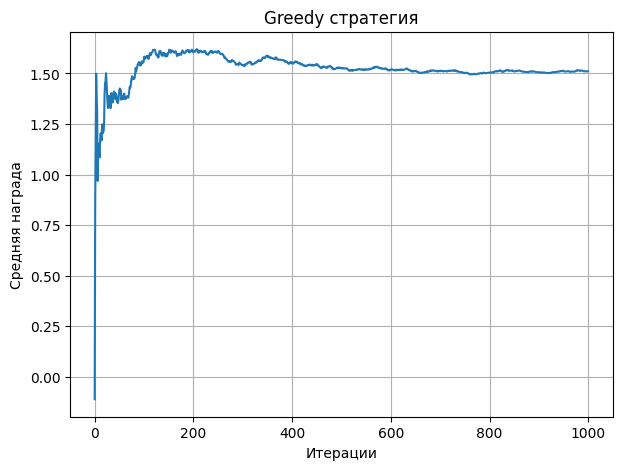

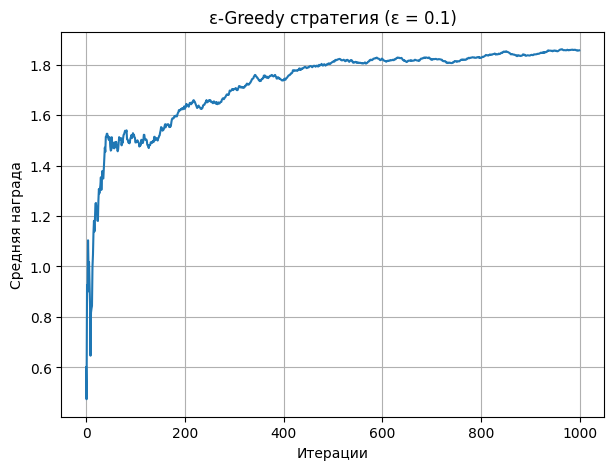

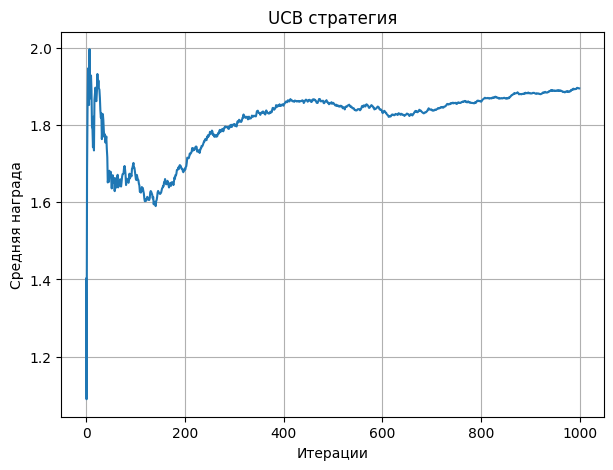

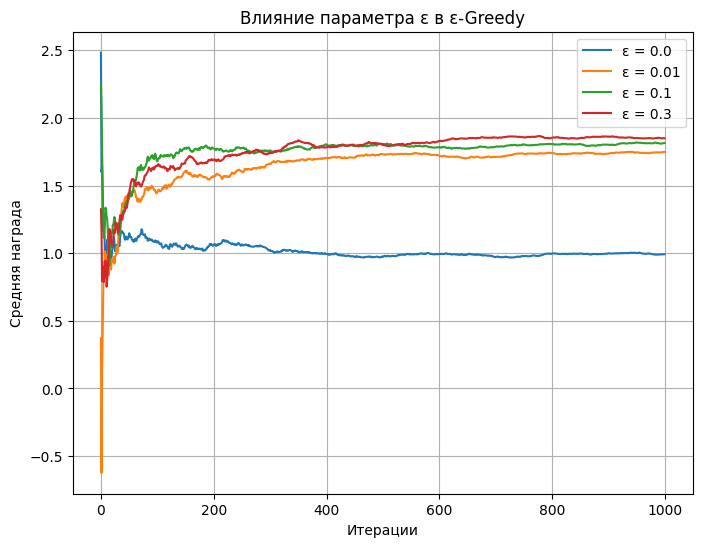


ВОПРОС 1:
Greedy всегда выбирает действие с максимальной текущей оценкой.
ε-Greedy с вероятностью ε выбирает случайное действие,
что позволяет исследовать новые варианты.

ВОПРОС 2:
Greedy может застрять в локальном оптимуме,
если изначально получил плохие оценки.
Исследование важно, чтобы обнаружить потенциально лучшие действия.

ВОПРОС 3:
Upper Confidence Bound (UCB) учитывает не только среднюю награду,
но и неопределенность оценки.
Редко используемые действия получают больший бонус,
что предотвращает преждевременную фиксацию на плохом выборе.

ВОПРОС 4:
Greedy использует только средние значения наград.
Thompson Sampling использует вероятностное распределение
и выбирает действие на основе случайной выборки из апостериорного распределения,
что обеспечивает более сбалансированное исследование.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ======================
# Среда
# ======================
class MultiArmedBandit:
    def __init__(self, true_means):
        self.true_means = true_means
        self.n_arms = len(true_means)

    def pull(self, arm):
        return np.random.normal(self.true_means[arm], 1.0)


# ======================
# Агент
# ======================
class GreedyAgent:
    def __init__(self, n_arms, epsilon=0.0, use_ucb=False, c=2.0):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.use_ucb = use_ucb
        self.c = c

        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.total_steps = 0

    def select_action(self):
        self.total_steps += 1

        # UCB
        if self.use_ucb:
            for i in range(self.n_arms):
                if self.counts[i] == 0:
                    return i
            ucb = self.values + self.c * np.sqrt(
                np.log(self.total_steps) / self.counts
            )
            return np.argmax(ucb)

        # ε-Greedy
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)

        return np.argmax(self.values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]


# ======================
# Эксперимент
# ======================
def run(agent, bandit, steps=1000):
    rewards = []
    for _ in range(steps):
        action = agent.select_action()
        reward = bandit.pull(action)
        agent.update(action, reward)
        rewards.append(reward)
    return np.cumsum(rewards) / (np.arange(len(rewards)) + 1)


true_means = [1.0, 1.5, 2.0, 1.2, 1.8]
bandit = MultiArmedBandit(true_means)
steps = 1000

# ======================
# ГРАФИК 1 — Greedy
# ======================
greedy_agent = GreedyAgent(n_arms=5)
greedy_rewards = run(greedy_agent, bandit, steps)

plt.figure(figsize=(7, 5))
plt.plot(greedy_rewards)
plt.title("Greedy стратегия")
plt.xlabel("Итерации")
plt.ylabel("Средняя награда")
plt.grid()
plt.show()


# ======================
# ГРАФИК 2 — ε-Greedy (фиксированное ε)
# ======================
eps_agent = GreedyAgent(n_arms=5, epsilon=0.1)
eps_rewards = run(eps_agent, bandit, steps)

plt.figure(figsize=(7, 5))
plt.plot(eps_rewards)
plt.title("ε-Greedy стратегия (ε = 0.1)")
plt.xlabel("Итерации")
plt.ylabel("Средняя награда")
plt.grid()
plt.show()


# ======================
# ГРАФИК 3 — UCB
# ======================
ucb_agent = GreedyAgent(n_arms=5, use_ucb=True, c=2.0)
ucb_rewards = run(ucb_agent, bandit, steps)

plt.figure(figsize=(7, 5))
plt.plot(ucb_rewards)
plt.title("UCB стратегия")
plt.xlabel("Итерации")
plt.ylabel("Средняя награда")
plt.grid()
plt.show()


# ======================
# ГРАФИК 4 — подбор ε (в одном графике)
# ======================
epsilons = [0.0, 0.01, 0.1, 0.3]

plt.figure(figsize=(8, 6))

for eps in epsilons:
    agent = GreedyAgent(n_arms=5, epsilon=eps)
    rewards = run(agent, bandit, steps)
    plt.plot(rewards, label=f"ε = {eps}")

plt.title("Влияние параметра ε в ε-Greedy")
plt.xlabel("Итерации")
plt.ylabel("Средняя награда")
plt.legend()
plt.grid()
plt.show()


# =========================
# Ответы на вопросы
# =========================
print("\nВОПРОС 1:")
print("Greedy всегда выбирает действие с максимальной текущей оценкой.")
print("ε-Greedy с вероятностью ε выбирает случайное действие,")
print("что позволяет исследовать новые варианты.")

print("\nВОПРОС 2:")
print("Greedy может застрять в локальном оптимуме,")
print("если изначально получил плохие оценки.")
print("Исследование важно, чтобы обнаружить потенциально лучшие действия.")

print("\nВОПРОС 3:")
print("Upper Confidence Bound (UCB) учитывает не только среднюю награду,")
print("но и неопределенность оценки.")
print("Редко используемые действия получают больший бонус,")
print("что предотвращает преждевременную фиксацию на плохом выборе.")

print("\nВОПРОС 4:")
print("Greedy использует только средние значения наград.")
print("Thompson Sampling использует вероятностное распределение")
print("и выбирает действие на основе случайной выборки из апостериорного распределения,")
print("что обеспечивает более сбалансированное исследование.")